# 3 · How volatile is bitcoin? It depends how closely you look

**The question:** we have every tick. Shouldn't that give a *perfect* estimate of volatility?

**Realized variance** (RV) is the sum of squared returns over the day:

$$RV = \sum_i r_i^2, \qquad r_i = \log p_{t_i} - \log p_{t_{i-1}}$$

Theory (for a continuous random walk) says RV converges to the true variance as you sample more often. So
more data should be better. With real tick data, the opposite can happen.

**The model.** What we observe isn't the "efficient" price m_t, but

$$p_t = m_t + u_t$$

where u_t is **microstructure noise**: bid–ask bounce, tick rounding, stale quotes. Over a long interval
the random walk m_t moves a lot and the noise is negligible. Over one tick the random walk barely moves and
the noise *is* the return. Every squared return then adds noise variance 2·Var(u), so RV ≈ true variance
+ 2n·Var(u), which **explodes** as the number of samples n grows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_quotes, load_trades, aggregate_trades
from micro.book import mid, to_ms, resample_last, time_grid
from micro.stats import acf
from micro.volatility import realized_variance, signature_plot, noise_variance, log_returns
from micro.plotting import style, save, BLUE, ORANGE, GREY, GREEN

style()
quotes = load_quotes()
trades = load_trades()
qts, m = to_ms(quotes.ts), mid(quotes)
p = trades.price.to_numpy()

def vol_pct(rv):
    """Daily RV -> daily volatility in percent."""
    return 100 * np.sqrt(rv)

## Effect 1: bid–ask bounce in trade prices

Trades alternate between the bid and the ask even when nothing fundamental changes. Buy at 70,000.1, sell
at 70,000.0, buy at 70,000.1: the "price" zig-zags by a tick each time. That zig-zag is pure noise, and it
shows up as **negative autocorrelation** of consecutive trade-price changes.

In [2]:
dp = np.diff(p)
print(f"lag-1 autocorrelation of trade-price changes: {acf(dp, 1)[1]:.3f}")
print(f"share of consecutive fills at the same price: {np.mean(dp == 0):.1%}")

lag-1 autocorrelation of trade-price changes: -0.358
share of consecutive fills at the same price: 61.8%


Strongly negative, as the bounce story predicts. Now compute RV using every k-th trade, for k from 1
(every tick) up to 5,000. This is sampling in **trade time** (tick time).

In [3]:
ks = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
rv_trade_time = [realized_variance(p[::k]) for k in ks]
for k, rv in zip(ks, rv_trade_time):
    print(f"every {k:>5} fills: {len(p) // k:>9,} returns, daily vol = {vol_pct(rv):.2f}%")

every     1 fills: 5,478,411 returns, daily vol = 9.67%
every     2 fills: 2,739,205 returns, daily vol = 7.81%
every     3 fills: 1,826,137 returns, daily vol = 6.71%
every     5 fills: 1,095,682 returns, daily vol = 5.91%
every    10 fills:   547,841 returns, daily vol = 4.82%
every    20 fills:   273,920 returns, daily vol = 4.11%
every    50 fills:   109,568 returns, daily vol = 3.69%
every   100 fills:    54,784 returns, daily vol = 3.55%
every   200 fills:    27,392 returns, daily vol = 3.55%
every   500 fills:    10,956 returns, daily vol = 3.50%
every  1000 fills:     5,478 returns, daily vol = 3.49%
every  2000 fills:     2,739 returns, daily vol = 3.50%
every  5000 fills:     1,095 returns, daily vol = 3.42%


Using every tick, BTC's daily volatility looks like **9.7%**. Sampling every few hundred trades, it settles
around **3.5%**. Same day, same prices. The tick-by-tick number is almost three times too big: nearly
90% of the tick-by-tick RV is noise.

We can back out the size of the noise: with n tick returns, E[RV] ≈ 2n·Var(u).

In [4]:
sd_u_trades = np.sqrt(noise_variance(p))
sd_u_mid = np.sqrt(noise_variance(m))
print(f"noise standard deviation, trade prices: {sd_u_trades * 1e4:.3f} bp  (~{sd_u_trades * p.mean():.2f} USDT)")
print(f"noise standard deviation, mid prices:   {sd_u_mid * 1e4:.3f} bp")
print(f"half the tick, for comparison:          {0.05 / p.mean() * 1e4:.3f} bp")

noise standard deviation, trade prices: 0.292 bp  (~2.04 USDT)
noise standard deviation, mid prices:   0.049 bp
half the tick, for comparison:          0.007 bp


Trade-price noise is about **0.3 bp (≈ 2 USDT)**, some forty times half a tick. Pure bid–ask bounce would
give half a tick. The rest comes from **sweeps**: a big order prints fills several dollars away, then the next
small trade prints back at the touch. The mid's noise is about 6x smaller. (The mid estimate is only rough:
the RV/2n formula assumes noise dominates every return, and we'll see next that mid returns behave differently.)

## Effect 2: the mid price under-reacts at very short horizons

Now use the **mid** (no bounce) and sample in **calendar time**, every 100 ms up to every 30 minutes.

In [5]:
freqs = ["100ms", "250ms", "500ms", "1s", "2s", "5s", "10s", "30s", "1min", "2min", "5min", "10min", "30min"]
seconds = pd.to_timedelta(freqs).total_seconds().to_numpy()
rv_mid = signature_plot(qts, m, freqs)
rv_trade = signature_plot(to_ms(trades.ts), p, freqs)
print(pd.DataFrame({"mid vol %": [vol_pct(rv_mid[f]) for f in freqs],
                    "trade-price vol %": [vol_pct(rv_trade[f]) for f in freqs]}, index=freqs).round(2))

       mid vol %  trade-price vol %
100ms       2.88               3.05
250ms       3.04               3.08
500ms       3.12               3.13
1s          3.17               3.18
2s          3.31               3.32
5s          3.47               3.47
10s         3.55               3.54
30s         3.59               3.55
1min        3.52               3.50
2min        3.48               3.46
5min        3.15               3.14
10min       3.40               3.39
30min       4.04               4.04


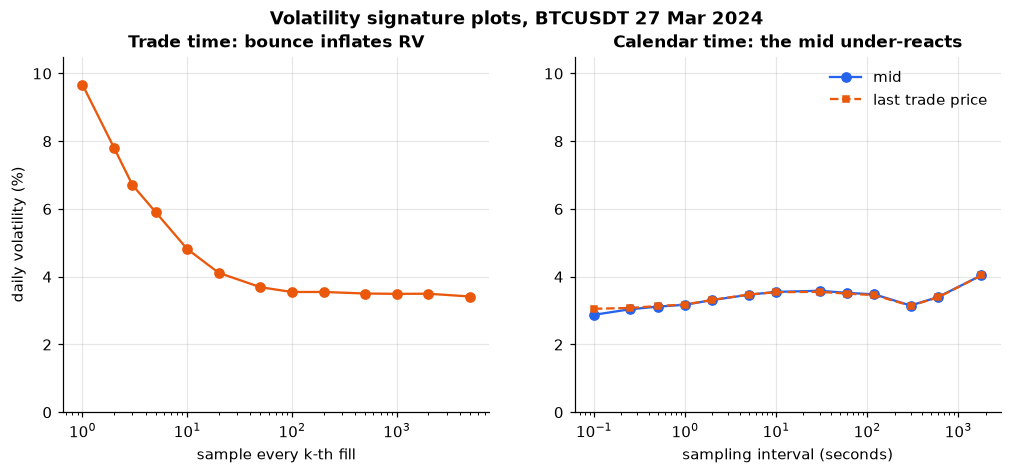

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.semilogx(ks, [vol_pct(v) for v in rv_trade_time], "o-", color=ORANGE)
ax.set(xlabel="sample every k-th fill", ylabel="daily volatility (%)", title="Trade time: bounce inflates RV", ylim=(0, 10.5))
ax = axes[1]
ax.semilogx(seconds, [vol_pct(rv_mid[f]) for f in freqs], "o-", color=BLUE, label="mid")
ax.semilogx(seconds, [vol_pct(rv_trade[f]) for f in freqs], "s--", color=ORANGE, ms=4, label="last trade price")
ax.set(xlabel="sampling interval (seconds)", title="Calendar time: the mid under-reacts", ylim=(0, 10.5))
ax.legend()
fig.suptitle("Volatility signature plots, BTCUSDT 27 Mar 2024", fontweight="bold")
save(fig, "03_signature_plot")

Two surprises in the right panel:

1. In calendar time, sampling every 100 ms gives *less* volatility (2.9%) than every 10 s (3.5%). The curve
   bends the "wrong" way: high-frequency mid returns are **positively** autocorrelated. Moves come in
   bursts: a sweep moves the mid several half-ticks over a few hundred milliseconds, and order flow is
   persistent (chapter 2), so information takes a moment to be fully reflected.
2. At 100 ms the trade price shows only a little bounce. Most 100 ms intervals contain zero or one trade,
   and the price only gets sampled at the end of each interval, so the bounce mostly cancels. The noise
   really bites in trade time.

The right end (10 min, 30 min) wobbles because a day contains only 144 ten-minute or 48 thirty-minute returns.
Low noise bias, but high *sampling variance*. That's the classic **bias–variance trade-off** in volatility estimation.

### Why positive autocorrelation lowers RV: the variance ratio

If one-period returns r have autocorrelations ρ_k, then the variance of a q-period return is

$$\frac{\mathrm{Var}(r_t + \dots + r_{t+q-1})}{q\,\mathrm{Var}(r_t)} = 1 + 2\sum_{k=1}^{q-1}\left(1 - \frac{k}{q}\right)\rho_k$$

This is the **variance ratio** (Lo & MacKinlay 1988). Positive ρ_k → ratio > 1 → long-horizon variance
exceeds the sum of short-horizon variances → RV at short horizons understates it. Negative ρ_k (bounce)
does the opposite. Let's verify with 100 ms mid returns.

In [7]:
grid = time_grid(qts[0], qts[-1], "100ms")
r = log_returns(resample_last(qts, m, grid))
rho = acf(r, 100)
q = 100   # 100 x 100ms = 10 s
vr_formula = 1 + 2 * np.sum((1 - np.arange(1, q) / q) * rho[1:q])
vr_actual = rv_mid["10s"] / rv_mid["100ms"]
print(f"100 ms mid-return autocorrelations, lags 1-5: {rho[1:6].round(3)}")
print(f"variance ratio predicted from autocorrelations: {vr_formula:.3f}")
print(f"actual RV(10 s) / RV(100 ms):                    {vr_actual:.3f}")

100 ms mid-return autocorrelations, lags 1-5: [ 0.069  0.036  0.019 -0.011  0.009]
variance ratio predicted from autocorrelations: 1.483
actual RV(10 s) / RV(100 ms):                    1.526


The autocorrelations predict most of the gap (1.48 vs 1.53; the rest is sampling error in the ACFs). The
signature plot is just the variance ratio in disguise.

## So what's the "right" volatility?

Practitioners' rule of thumb: sample every **5 minutes** (Andersen, Bollerslev and co., early 2000s), or
wherever the signature plot flattens. Here that's anywhere from 10 s to 5 min, about **3.2–3.6% for the
day**, roughly 65% annualised (× √365, since crypto trades every day). Better estimators use all the data
while correcting for noise: two-scale RV (Zhang, Mykland & Aït-Sahalia 2005), realized kernels
(Barndorff-Nielsen et al. 2008) and pre-averaging.

---
### Interview angle

<details><summary><b>"You compute volatility from tick data and get a number 3x higher than from daily closes. What happened?"</b></summary>

Microstructure noise. Bid–ask bounce makes consecutive trade-price changes negatively autocorrelated, so
summing squared tick returns adds 2·Var(noise) per observation. Fixes: sample sparser (5 min), use mids instead
of trades, or use a noise-robust estimator (two-scale RV, realized kernel).
</details>

<details><summary><b>"Daily vol is 3.5%. What's the 1-minute vol? The 1-year vol?"</b></summary>

Under a random walk, variance scales with time: σ_T = σ_daily·√(T / 1 day). One minute: 3.5% / √1440 ≈ 0.09%,
about 9 bp ≈ $65 on $70k BTC. One year: 3.5% × √365 ≈ 67% (crypto trades 365 days; for stocks use √252).
Caveat: this √t rule is exactly what fails at very short horizons. That's this whole chapter.
</details>

<details><summary><b>"Returns have lag-1 autocorrelation −0.36. Is there a trading strategy?"</b></summary>

It's bid–ask bounce: trade prices alternate between bid and ask. To "buy low", you'd have to buy at the bid,
which means being a maker and waiting to be filled. To exploit it as a taker you'd pay the spread, which is
exactly the size of the bounce. The autocorrelation *is* the spread, not an inefficiency. (Chapter 4 turns
this into a spread estimator.)
</details>

### Try this yourself
1. Implement the two-scale estimator: TSRV = RV_avg(K) − (n̄/n)·RV_all, where RV_avg(K) averages the RVs of K
   offset subsamples taken every K ticks. Does it land near 3.5% using all 5.5 million trades?
2. Compute the signature plot hour by hour. Is the noise *share* larger in quiet hours?